In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumithsingh/blood-cell-images-for-cancer-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection


In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Path to the downloaded dataset
dataset_path = path

# Define destination directories for training and validation sets
train_dir = 'dataset_split/train'
val_dir = 'dataset_split/val'

# Create directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

print(f"Original dataset found at: {dataset_path}")

# Get a list of subdirectories (classes) in the dataset
# Assume dataset_path contains subdirectories, each representing a class
# Example: dataset_path/class1/, dataset_path/class2/

# Search for the subdirectory containing the sub-classes within dataset_path. Often, datasets from Kagglehub
# will have a single sub-folder containing all images or subsequent sub-folders.
# Trying to find 'dataset_path/blood-cell-images-for-cancer-detection/'

subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# If there's a single subdirectory that seems to be the dataset's root, dive into it
if len(subdirs) == 1 and os.path.isdir(os.path.join(dataset_path, subdirs[0])):
    actual_data_path = os.path.join(dataset_path, subdirs[0])
    print(f"Detected actual data directory at: {actual_data_path}")
else:
    actual_data_path = dataset_path
    print(f"Using the root path as the actual data path: {actual_data_path}")

# Now get the list of classes from actual_data_path
classes = [d for d in os.listdir(actual_data_path) if os.path.isdir(os.path.join(actual_data_path, d))]

if not classes:
    print(f"No class directories found in {actual_data_path}. Please check the dataset structure.")
else:
    print(f"Found classes: {classes}")

    # Split each class into training and validation sets
    for class_name in classes:
        class_path = os.path.join(actual_data_path, class_name)
        images = [os.path.join(class_path, img) for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

        if not images:
            print(f"No images found in class {class_name}")
            continue

        # Split images into training and validation (80% train, 20% validation)
        train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

        # Create class subdirectories in train and val directories
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

        # Copy images to their respective directories
        for img_file in train_images:
            shutil.copy(img_file, os.path.join(train_dir, class_name, os.path.basename(img_file)))
        for img_file in val_images:
            shutil.copy(img_file, os.path.join(val_dir, class_name, os.path.basename(img_file)))

        print(f"Class '{class_name}' split: {len(train_images)} images for training, {len(val_images)} images for validation.")

    print("Dataset splitting process completed.")
    print(f"Training set saved at: {train_dir}")
    print(f"Validation set saved at: {val_dir}")

Original dataset found at: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection
Using the root path as the actual data path: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection
Found classes: ['monocyte', 'basophil', 'erythroblast', 'seg_neutrophil', 'myeloblast']
Class 'monocyte' split: 800 images for training, 200 images for validation.
Class 'basophil' split: 800 images for training, 200 images for validation.
Class 'erythroblast' split: 800 images for training, 200 images for validation.
Class 'seg_neutrophil' split: 800 images for training, 200 images for validation.
Class 'myeloblast' split: 800 images for training, 200 images for validation.
Dataset splitting process completed.
Training set saved at: dataset_split/train
Validation set saved at: dataset_split/val


## GPU Check

In [3]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus}")
    # Set TensorFlow to use GPU if available
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. TensorFlow will run on CPU.")


2026-06-13 04:09:51.063344: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781323791.252812      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781323791.310056      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781323791.755708      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781323791.755754      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781323791.755757      58 computation_placer.cc:177] computation placer alr

GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## DenseNet Model Building and Training

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define image dimensions and batch size
img_height, img_width = 224, 224
batch_size = 32
num_classes = len(classes) # 'classes' variable from previous cell

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Load pre-trained DenseNet121 model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


I0000 00:00:1781323804.588436      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,092,229 (30.87 MB)

 Trainable params: 1,054,725 (4.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [5]:
# Train the model
epochs = 10 # You can adjust the number of epochs
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)


Epoch 1/10


I0000 00:00:1781323823.075339     138 service.cc:152] XLA service 0x7a2c64005d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781323823.075389     138 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781323826.610568     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/125 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.1875 - loss: 1.6644  

I0000 00:00:1781323838.562897     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 88s 476ms/step - accuracy: 0.8278 - loss: 0.6289 - val_accuracy: 0.9375 - val_loss: 0.2859
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.9457 - loss: 0.2460 - val_accuracy: 0.9435 - val_loss: 0.1950
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.9510 - loss: 0.1800 - val_accuracy: 0.9385 - val_loss: 0.1882
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 380ms/step - accuracy: 0.9640 - loss: 0.1435 - val_accuracy: 0.9607 - val_loss: 0.1319
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 373ms/step - accuracy: 0.9650 - loss: 0.1239 - val_accuracy: 0.9677 - val_loss: 0.1138
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.9682 - loss: 0.1162 - val_accuracy: 0.9728 - val_loss: 0.1039
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 372ms/step - accuracy: 0.9710 - loss: 0.0983 - val_accuracy: 0.9657 - val_loss: 0.1055
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.9730 - loss: 0.0941 - val

## Training Results Summary

In [6]:
# Evaluate the model on the validation set
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Display last epoch's training/validation metrics
print("\nLast Epoch Training Metrics:")
print(f"  Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 417ms/step - accuracy: 0.9700 - loss: 0.0863
Validation Loss: 0.0863
Validation Accuracy: 0.9700

Last Epoch Training Metrics:
  Training Loss: 0.0801
  Training Accuracy: 0.9768
  Validation Loss: 0.0870
  Validation Accuracy: 0.9698


## Training History Plot

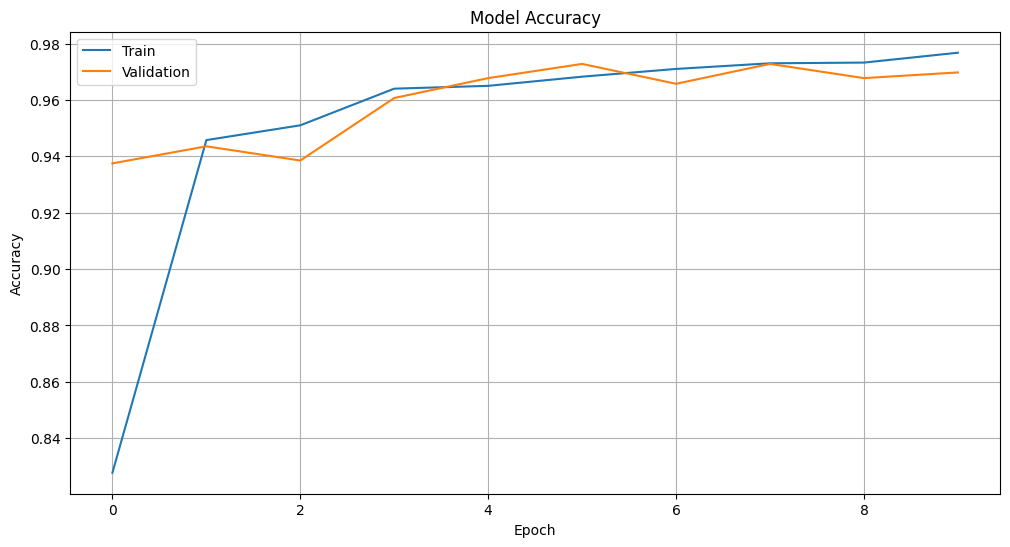

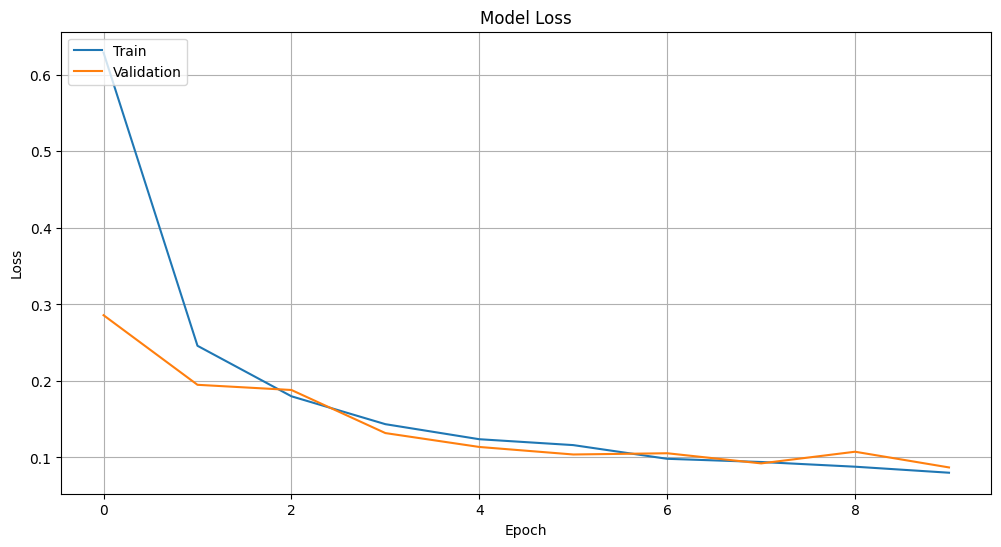

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()
